# TEAM7 777777777777～ remember！ 77777777777

## Model Overview

**the model is in F1ModelBuild.ipynb**

group rank

S1G2,

S2G4,

S1G1,

S1G3,

S1G6,

S1G5,

S1G8,

S2G3,

S2G1,

S1G4,

S2G2

10 of 20 (+_ 1)

3 of top 3 

8 of 10 (total)


### Core Model Formula

The expected finishing position for driver $d$ in race $r$:

$$y_{d,r} \sim \text{Normal}(\mu_{d,r}, \sigma_{race}^2)$$
where $y_{d,r}$ is the observed finishing position
$$\mu_{d,r} = \alpha + \beta_{team[d]} + \gamma_d + \eta_p + \delta_{track[r]} \cdot adaptation_d + \epsilon_{trend} \cdot recent_{3d} + \zeta_{dnf} \cdot DNF\_risk_d$$



### parameters definitions:

- $\alpha$ = baseline position (overall field average ≈ 10.6)

- $ β_{team[d]​} = $ team(constructor) ability (drive d belongs to team t)

- $ γ_{d​} = $ driver ability (event in the same team , 2 driver has different abilities) 

- $\eta_(p) $ = start position

- $δ_{track[r]} = $ track are defined into 3 different type (high/ mid/ low speed )

- $adaptation_{d} = $ each driver has different ability to adjust according to the types of track

- $ϵ_{trend​} = $ how driver's trend influence next competition 

- $recent3_{d}=$ driver is  improving, maintaining consistency, or regressing

- $ζ_{dnf​} = $ the influence on the rank because of DNF
  
- $DNF\_risk_{d} = $ driver's probability of DNF

- $ \sigma^2  = $ the unpredictable issues

---

###  Team Effects

**$\beta_{team}$ (beta_team)**— Team performance effect

$$\beta_{team} \sim \text{Normal}(\mu_{tier}, \sigma_{tier})$$

Where:

$$\mu_{tier} = \begin{cases} -12 & \text{for top teams (McLaren, Red Bull, Ferrari)} \\ -5 & \text{for mid teams (Mercedes, Aston Martin)} \\ 0 & \text{for lower teams (Williams, Haas, Sauber, etc.)} \end{cases}$$

$$\sigma_{tier} = 2$$


Driver features columns:
['Driver', 'Team', 'TotalPoints', 'TotalRaces', 'FinishedRaces', 'DNFRate', 'AvgPosition', 'Recent5Avg', 'HighSpeedAvg', 'HighSpeedRaces', 'BalancedAvg', 'BalancedRaces', 'TechnicalAvg', 'TechnicalRaces']

First few rows:
         Driver             Team  TotalPoints  TotalRaces  FinishedRaces  \
0  M VERSTAPPEN  Red Bull Racing        720.0          46             43   
1      L NORRIS          McLaren        696.0          46             41   
2     O PIASTRI          McLaren        616.0          46             44   
3     C LECLERC          Ferrari        551.0          46             42   
4     G RUSSELL         Mercedes        531.0          46             43   

    DNFRate  AvgPosition  Recent5Avg  HighSpeedAvg  HighSpeedRaces  \
0  0.065217     3.116279        2.00      2.882353              17   
1  0.108696     2.926829        1.75      4.187500              16   
2  0.043478     4.045455        4.75      3.733333              15   
3  0.086957     

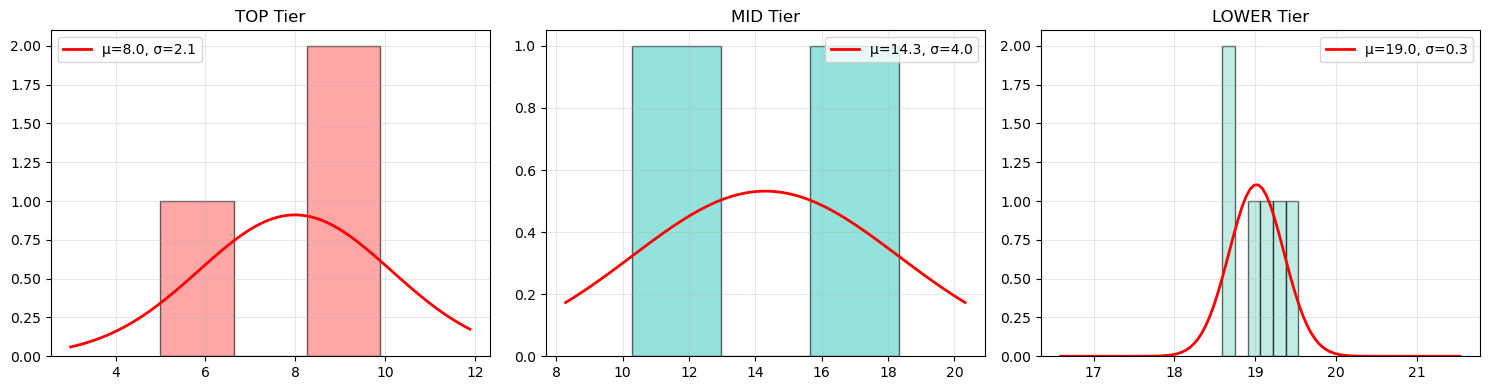


RECOMMENDED PRIORS FOR PYMC:

alpha = pm.Normal('alpha', mu=15.15, sigma=2)

mu_tier = [-7.16, -0.85, 3.86]

sigma_tier = pm.HalfNormal('sigma_tier', 2.17)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =================== LOAD DATA ===================
teams_info = pd.read_csv('teams_info.csv')
driver_features = pd.read_csv('driver_features.csv')

print("Driver features columns:")
print(driver_features.columns.tolist())
print("\nFirst few rows:")
print(driver_features.head())

# =================== CALCULATE TEAM AVERAGE POSITION ===================

team_performance = teams_info.copy()
team_performance['AvgFinish'] = 20 - (team_performance['TotalPoints'] / team_performance['TotalPoints'].max()) * 15

print("\n" + "="*50)
print("Team Performance (estimated from points):")
print(team_performance[['Team', 'TotalPoints', 'Tier', 'AvgFinish']].sort_values('AvgFinish'))

# =================== FIT NORMAL DISTRIBUTIONS ===================

tiers = ['top', 'mid', 'lower']
tier_params = {}

overall_mean = team_performance['AvgFinish'].mean()
print(f"\nBaseline α: {overall_mean:.2f}")

print("\n" + "="*50)
for tier in tiers:
    tier_data = team_performance[team_performance['Tier'] == tier]['AvgFinish']
    
    if len(tier_data) > 0:
        mu, sigma = stats.norm.fit(tier_data)
        tier_params[tier] = {'mu': mu, 'sigma': sigma}
        
        print(f"\n{tier.upper()} tier (n={len(tier_data)}):")
        print(f"  μ = {mu:.2f}, σ = {sigma:.2f}")
        print(f"  Centered μ: {mu - overall_mean:.2f}")

# =================== PLOT ===================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

for idx, tier in enumerate(tiers):
    ax = axes[idx]
    tier_data = team_performance[team_performance['Tier'] == tier]['AvgFinish']
    
    if len(tier_data) > 0:
        ax.hist(tier_data, bins=max(3, len(tier_data)), alpha=0.6, 
                color=colors[idx], edgecolor='black')
        
        mu, sigma = tier_params[tier]['mu'], tier_params[tier]['sigma']
        x = np.linspace(tier_data.min()-2, tier_data.max()+2, 100)
        ax.plot(x, stats.norm.pdf(x, mu, sigma) * len(tier_data) * 
                (tier_data.max()-tier_data.min())/max(3, len(tier_data)), 
                'r-', lw=2, label=f'μ={mu:.1f}, σ={sigma:.1f}')
        
        ax.set_title(f'{tier.upper()} Tier')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('team_tiers.png', dpi=200)
plt.show()

# =================== PYMC PRIORS ===================

print("\n" + "="*50)
print("RECOMMENDED PRIORS FOR PYMC:")
print("="*50)
print(f"\nalpha = pm.Normal('alpha', mu={overall_mean:.2f}, sigma=2)")

mu_tier_values = [tier_params[t]['mu']-overall_mean for t in tiers]
print(f"\nmu_tier = [{mu_tier_values[0]:.2f}, {mu_tier_values[1]:.2f}, {mu_tier_values[2]:.2f}]")

pooled_sigma = np.mean([p['sigma'] for p in tier_params.values()])
print(f"\nsigma_tier = pm.HalfNormal('sigma_tier', {pooled_sigma:.2f})")

---

###  Driver Ability

**$\gamma_d$ (gamma_driver)** — Individual driver skill effect

$$\gamma_d \sim \text{Normal}(0, \sigma_{driver}^2)$$

**$\sigma_{driver}$ (sigma_driver)** — Standard deviation of driver abilities

$$\sigma_{driver} \sim \text{HalfNormal}(2.0)$$



In [ ]:
import pandas as pd
import numpy as np

driver_features = pd.read_csv('driver_features.csv')

# Calculate teammate differences
team_variance = driver_features.groupby('Team')['AvgPosition'].std().dropna()

pooled_std = team_variance.mean()
print(f"Estimated σ_driver: {pooled_std:.2f}")

# This is your HalfNormal scale parameter!
print(f"\nRecommended prior:")
print(f"σ_driver ~ HalfNormal({pooled_std:.2f})")

Estimated σ_driver: 2.00

Recommended prior:
σ_driver ~ HalfNormal(2.00)


---

### Effective Influencers 

**$\alpha$ (alpha)** — Overall baseline finishing position

$$\alpha \sim \text{Normal}(10.6, 2)$$


**$\delta_{track}$ (delta_track)** — Track type effect (3 types)

$$\delta_{track} \sim \text{Normal}(0, 2) \quad \text{shape} = 3$$

Where track types are:
- Index 0: High-speed (Monza, Spa, Bahrain)
- Index 1: Balanced (Australia, Silverstone)
- Index 2: Technical (Monaco, Hungary, Singapore)

**$\epsilon_{trend}$ (epsilon_trend)** — Recent form/momentum coefficient

$$\epsilon_{trend} \sim \text{Normal}(0, 3.5)$$

**$\zeta_{dnf}$ (zeta_dnf)** — DNF risk penalty

$$\zeta_{dnf} \sim \text{HalfNormal}(3.5)$$

**$\sigma_{race}$ (sigma_race)** — Residual race variance

$$\sigma_{race} \sim \text{HalfNormal}(1.0)$$


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Load data
driver_features = pd.read_csv('driver_features.csv')

# Standardize features
scaler = StandardScaler()
features = ['Recent5Avg', 'BalancedAvg', 'DNFRate']
driver_features[features] = scaler.fit_transform(driver_features[features])


# 1. Track adaptation δ
X_track = driver_features[['BalancedAvg']].values
y = driver_features['AvgPosition'].values
beta_track = LinearRegression().fit(X_track, y).coef_[0]

# 2. Recent form ε
X_trend = driver_features[['Recent5Avg']].values
beta_trend = LinearRegression().fit(X_trend, y).coef_[0]

# 3. DNF penalty ζ
X_dnf = driver_features[['DNFRate']].values
beta_dnf = abs(LinearRegression().fit(X_dnf, y).coef_[0])

# 4. Race variance σ
# Fit full model and get residuals (simplified here)
X_full = driver_features[features].values
full_model = LinearRegression().fit(X_full, y)
residuals = y - full_model.predict(X_full)
sigma_race = np.std(residuals)

print("="*60)
print("DATA-DRIVEN PRIORS:")
print("="*60)
print(f"δ_track ~ Normal(0, {abs(beta_track):.2f})")
print(f"ε_trend ~ Normal(0, {abs(beta_trend):.2f})")
print(f"ζ_dnf ~ HalfNormal({beta_dnf:.2f})")
print(f"σ_race ~ HalfNormal({sigma_race:.2f})")

DATA-DRIVEN PRIORS:
δ_track ~ Normal(0, 3.51)
ε_trend ~ Normal(0, 3.32)
ζ_dnf ~ HalfNormal(3.42)
σ_race ~ HalfNormal(0.97)


**$\eta_{p}$ (eta_grid)** — Starting position effect (Assuming the starting postion h

$$\eta_{p} \sim \text{Normal}(0, 0.5)$$

In [ ]:
# checking correlation 没用是因为 排位赛决定了最接近的一场的水平 这个反应了 水平
#  起始点的位置对最后的结果也有影响 但是两个太接近了，相当于一个参数使用了两次，所以只用了一个
race_results = pd.read_csv('race_results_processed.csv')
print(race_results[['GridPosition', 'QualifyingPosition']].corr())

                    GridPosition  QualifyingPosition
GridPosition            1.000000            0.973543
QualifyingPosition      0.973543            1.000000


##### the total model looks like


~~~python
with pm.Model() as hierarchical_f1_model:

    # level 1 priori team
    tier_mean_vals = [-12,-5,0]
    tier_std_val = 2
    team_tier_coef = pm.Normal('beta_team',mu=tier_mean_vals,sigma=tier_std_val,shape=3)
    # level 2 driver ability
    driver_ability_std = pm.HalfNormal('sigma_driver',2.0)
    driver_ability_coef = pm.Normal('gamma_driver',mu =0,sigma = driver_ability_std, shape = total_drivers)
    # level 3 settings
    intercept_param = pm.Normal('alpha', mu=10.6, sigma=2)
    # track_effect_param = pm.Normal('delta_track', mu=0, sigma=3.5)
    starting_grid_coef = pm.Normal('eta_grid', mu=0, sigma=0.5)
    recent_form_coef = pm.Normal('epsilon_trend', mu=0, sigma=3.5)
    reliability_penalty = pm.HalfNormal('zeta_dnf', 3.5)
    # race_noise_param = pm.HalfNormal('sigma_race', 1.0) 

    # Track type effects (3 types: high_speed, balanced, technical)
    track_effect_param = pm.Normal('delta_track', mu=0, sigma=2, shape=3)
    race_noise_param = pm.HalfNormal('sigma_race', 1.0)
    qualifying_coef = pm.Normal('xi_quali', mu=0, sigma=0.8)  

    circuit_encoding = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    historical_races['TrackTypeIdx'] = historical_races['TrackType'].map(circuit_encoding).astype(int)

    # Convert to numpy arrays and ensure integer type
    tier_idx = historical_races['TierCode'].values.astype(int)
    driver_idx = historical_races['DriverIdx'].values.astype(int)
    track_idx = historical_races['TrackTypeIdx'].values.astype(int)
    
    # likelyhood
    predicted_finish = (
        intercept_param +
        team_tier_coef[tier_idx] +
        driver_ability_coef[driver_idx] +  # using driver index!
        starting_grid_coef * historical_races['GridPosition'].values +
        # qualifying_coef * historical_races['QualifyingPosition'].values +
        track_effect_param[track_idx]*driver_ability_coef[driver_idx] +  # Track type effect
        recent_form_coef * historical_races['Recent5Avg'].values +
        reliability_penalty * historical_races['CumDNFRate'].values
    )
    observed_finish = pm.Normal(
        'y_obs', 
        mu=predicted_finish, 
        sigma=race_noise_param,
        observed=historical_races['EffectivePosition'].values  # 440 observations!
        # observed=historical_races['QualifyingPosition'].values  # 440 observations!
    )
~~~

### Model Fitting Challenges

Due to the model containing multiple hierarchical effects (team tier, driver ability, grid position, recent performance, DNF rate, etc.) and interaction terms (such as team tier × driver ability), the parameter space is relatively complex, leading to the following challenges in the sampling process:

#### Initialization Sensitivity Issues
- **Random Seed Dependency**: Different `random_seed` values lead to different initial sampling positions, and some initial positions may fall into low-probability regions
- **Solution**: Try multiple random seeds (e.g., `random_seed=42, 123, 456`) and select the result with the best convergence performance

#### Sampling Strategies

**Parallel Multiple Chains**:
```python
with model:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,  # Use 4 independent chains
        random_seed=42,
        target_accept=0.99
    )
```
- Use `chains=4` to ensure sampling starts from different initial positions
- Check between-chain convergence through R-hat values (R-hat ≈ 1.0 indicates good convergence)
- Multiple chains can explore the parameter space more reliably

**Baby Step Strategy**:
```python
# Step 1: Fit simplified model first
with simple_model:
    simple_trace = pm.sample(1000, tune=1000, chains=2)

# Step 2: Use posterior from simplified model as prior for full model
with full_model:
    # Initialize parameters with means from simple_trace
    start = {
        'team_effect': simple_trace.posterior['team_effect'].mean(dim=['chain', 'draw']),
        'driver_effect': simple_trace.posterior['driver_effect'].mean(dim=['chain', 'draw'])
    }
    trace = pm.sample(2000, tune=2000, chains=4, initvals=start)
```

Or gradually increase model complexity:
1. First fit a baseline model with only team effects
2. Add driver effects
3. Add grid position and other covariates
4. Finally add interaction terms

This progressive approach helps the model find reasonable parameter regions from simple to complex, avoiding convergence difficulties when directly fitting complex models.

#### Convergence Diagnostics
```python
# Check convergence metrics
print(az.summary(trace, var_names=['team_effect', 'driver_effect', 'beta_grid']))
# Focus on r_hat < 1.01, ess_bulk > 400
```

## Data Collection and Cleaning

**Code Location**: `F1DataGet/`

### Data Sources
Used **FastF1 Library** to collect F1 race data from 2025 seasons with local caching to avoid redundant API calls.
```python
import fastf1

```

### Key Variables Collected
- **Race Results**: Final positions, grid positions, DNF status
- **Driver Data**: Names, teams, historical performance

### Data Processing
- **Team Data**: Constructor Tier Code, Driver Index, Average For Recent Few Matches
- **Track Info**: Circuit types and characteristics




# predict 

the file is **F1 Predict ABU DHABI.ipynb**

### Why Monte Carlo Simulation?

#### The Ranking Constraint Problem

The Normal likelihood function treats each driver's finishing position **independently**, which creates a fundamental issue:

- **Independent predictions violate racing constraints**: In reality, race positions are **strictly ranked** (1st, 2nd, ..., 20th) with no ties or duplicates
- **Probability violation**: When we independently predict each driver's position, the sum of "P(Win)" across all drivers can exceed 100%, which is mathematically impossible
- **Correlated outcomes**: If Driver A finishes 1st, Driver B **cannot** also finish 1st - positions are mutually exclusive

The hierarchical model estimates continuous latent scores ($\mu_d$) for each driver, but **does not enforce ranking constraints** during posterior sampling.

## Monte Carlo Solution

To generate realistic race predictions that respect ranking constraints, we use **Monte Carlo simulation**:

### Algorithm

For each simulation iteration $s = 1, \ldots, S$:

1. **Sample posterior parameters**: Draw one sample from the posterior distribution
   $$\theta^{(s)} \sim p(\theta \mid \text{data})$$

2. **Generate latent scores**: For each driver $d$, sample a continuous score
   $$\tilde{y}_d^{(s)} \sim \text{Normal}(\mu_d^{(s)}, \sigma_{race}^{(s)})$$

3. **Apply ranking transformation**: Convert continuous scores to discrete ranks
   $$\text{rank}_d^{(s)} = \text{argsort}(\tilde{y}_1^{(s)}, \ldots, \tilde{y}_N^{(s)}) + 1$$
   
   This ensures: $\text{rank}_d^{(s)} \in \{1, 2, \ldots, 20\}$ with no duplicates

4. **Accumulate results**: Record the simulated position for each driver

### Output Statistics

After $S$ simulations, we compute:

- **Position probability distribution**: $P(\text{Driver } d \text{ finishes in position } k) = \frac{1}{S}\sum_{s=1}^{S} \mathbb{1}[\text{rank}_d^{(s)} = k]$
- **Expected position**: $\mathbb{E}[\text{rank}_d] = \sum_{k=1}^{20} k \cdot P(\text{rank}_d = k)$
- **Mode (most likely position)**: $\text{mode}[\text{rank}_d] = \arg\max_k P(\text{rank}_d = k)$
- **Winning probability**: $P(\text{rank}_d = 1)$
- **Podium probability**: $P(\text{rank}_d \leq 3)$

### Key Benefits

✅ **Enforces ranking constraints**: Every simulation produces exactly one 1st place, one 2nd place, etc.

✅ **Realistic probabilities**: $\sum_{d=1}^{N} P(\text{Driver } d \text{ wins}) = 1.0$ exactly

✅ **Captures uncertainty**: By sampling from the posterior, we propagate parameter uncertainty into position predictions

✅ **Handles correlations**: The ranking transformation implicitly models the competitive structure where one driver's success affects others' positions

---

#### Implementation Details

We run $S = 500{,}000$ Monte Carlo iterations to ensure stable probability estimates with minimal sampling error.

## result

**in file F1 ABU DHABI.ipynb file**

## result of model

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt


In [ ]:
trace = az.from_netcdf('model/f1_trace.nc')

# ============================================================================
# POSTERIOR SUMMARIES
# ============================================================================

print("\n" + "="*70)
print("POSTERIOR ESTIMATES")
print("="*70)


summary = az.summary(trace,var_names=['alpha','beta_team','gamma_driver'])
summary


POSTERIOR ESTIMATES


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,10.285,1.373,7.754,12.955,0.018,0.012,6031.0,7361.0,1.0
beta_team[0],-7.355,1.136,-9.519,-5.270,0.016,0.009,5310.0,8007.0,1.0
beta_team[1],-5.833,1.152,-7.985,-3.664,0.015,0.010,5674.0,8924.0,1.0
beta_team[2],-4.233,1.223,-6.552,-1.986,0.020,0.010,3756.0,6573.0,1.0
gamma_driver[0],-0.254,0.609,-1.501,0.840,0.007,0.008,9311.0,8279.0,1.0
gamma_driver[1],-0.402,0.640,-1.732,0.683,0.011,0.008,3740.0,7358.0,1.0
gamma_driver[2],-0.095,0.605,-1.307,1.061,0.005,0.010,15363.0,8595.0,1.0
gamma_driver[3],-0.051,0.593,-1.211,1.137,0.005,0.010,16473.0,7195.0,1.0
gamma_driver[4],0.965,0.887,-0.309,2.656,0.027,0.010,916.0,5328.0,1.0
gamma_driver[5],-0.258,0.654,-1.638,0.880,0.009,0.010,6844.0,7036.0,1.0


In [5]:
# Extract posterior means
alpha_mean = trace.posterior['alpha'].mean().values
beta_car_mean = trace.posterior['beta_team'].mean(dim=['chain', 'draw']).values
gamma_driver_mean = trace.posterior['gamma_driver'].mean(dim=['chain', 'draw']).values
sigma_mean = trace.posterior['sigma_race'].mean().values

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

print("\n🏎️  CAR PERFORMANCE:")
print(f"  McLaren/Red Bull effect: {beta_car_mean[0]:.3f} (negative = faster)")

print("\n🏁  DRIVER SKILLS (beyond car):")
print(f"  Max Verstappen: {gamma_driver_mean[1]:.3f}")
print(f"  Lando Norris: {gamma_driver_mean[2]:.3f}")
print(f"  Oscar Piastri: {gamma_driver_mean[3]:.3f}")



INTERPRETATION

🏎️  CAR PERFORMANCE:
  McLaren/Red Bull effect: -7.355 (negative = faster)

🏁  DRIVER SKILLS (beyond car):
  Max Verstappen: -0.402
  Lando Norris: -0.095
  Oscar Piastri: -0.051



GENERATING VISUALIZATIONS


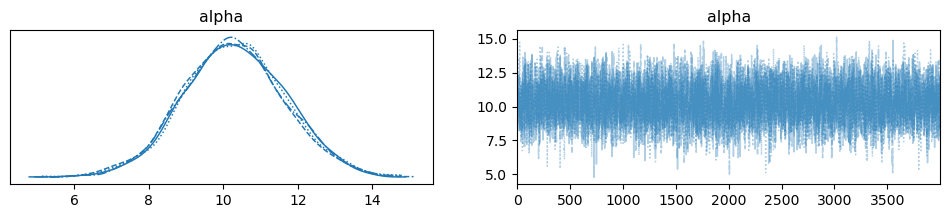

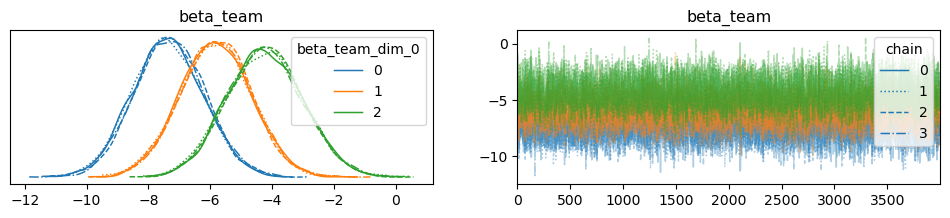

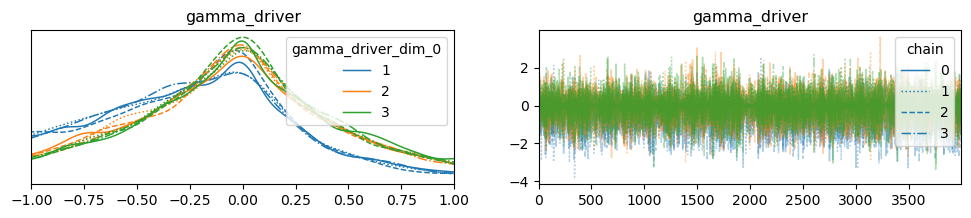

In [6]:
# ============================================================================
# VISUALIZATION
# ============================================================================
##Max Vestappen 第三行左边的图里，distribution的left tail高，right tail低，说明他很强，大概率提升成绩
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# 1. Trace plots for key parameters
az.plot_trace(trace, var_names=['alpha'], combined=False)
az.plot_trace(trace, var_names=['beta_team'], combined=False,legend = True)
ax= az.plot_trace(trace, var_names=['gamma_driver'], coords={'gamma_driver_dim_0': [1, 2, 3]},combined=False,legend = True)
ax[0, 0].set_xlim(-1.0, 1.)
plt.show()

### result for Dhabi

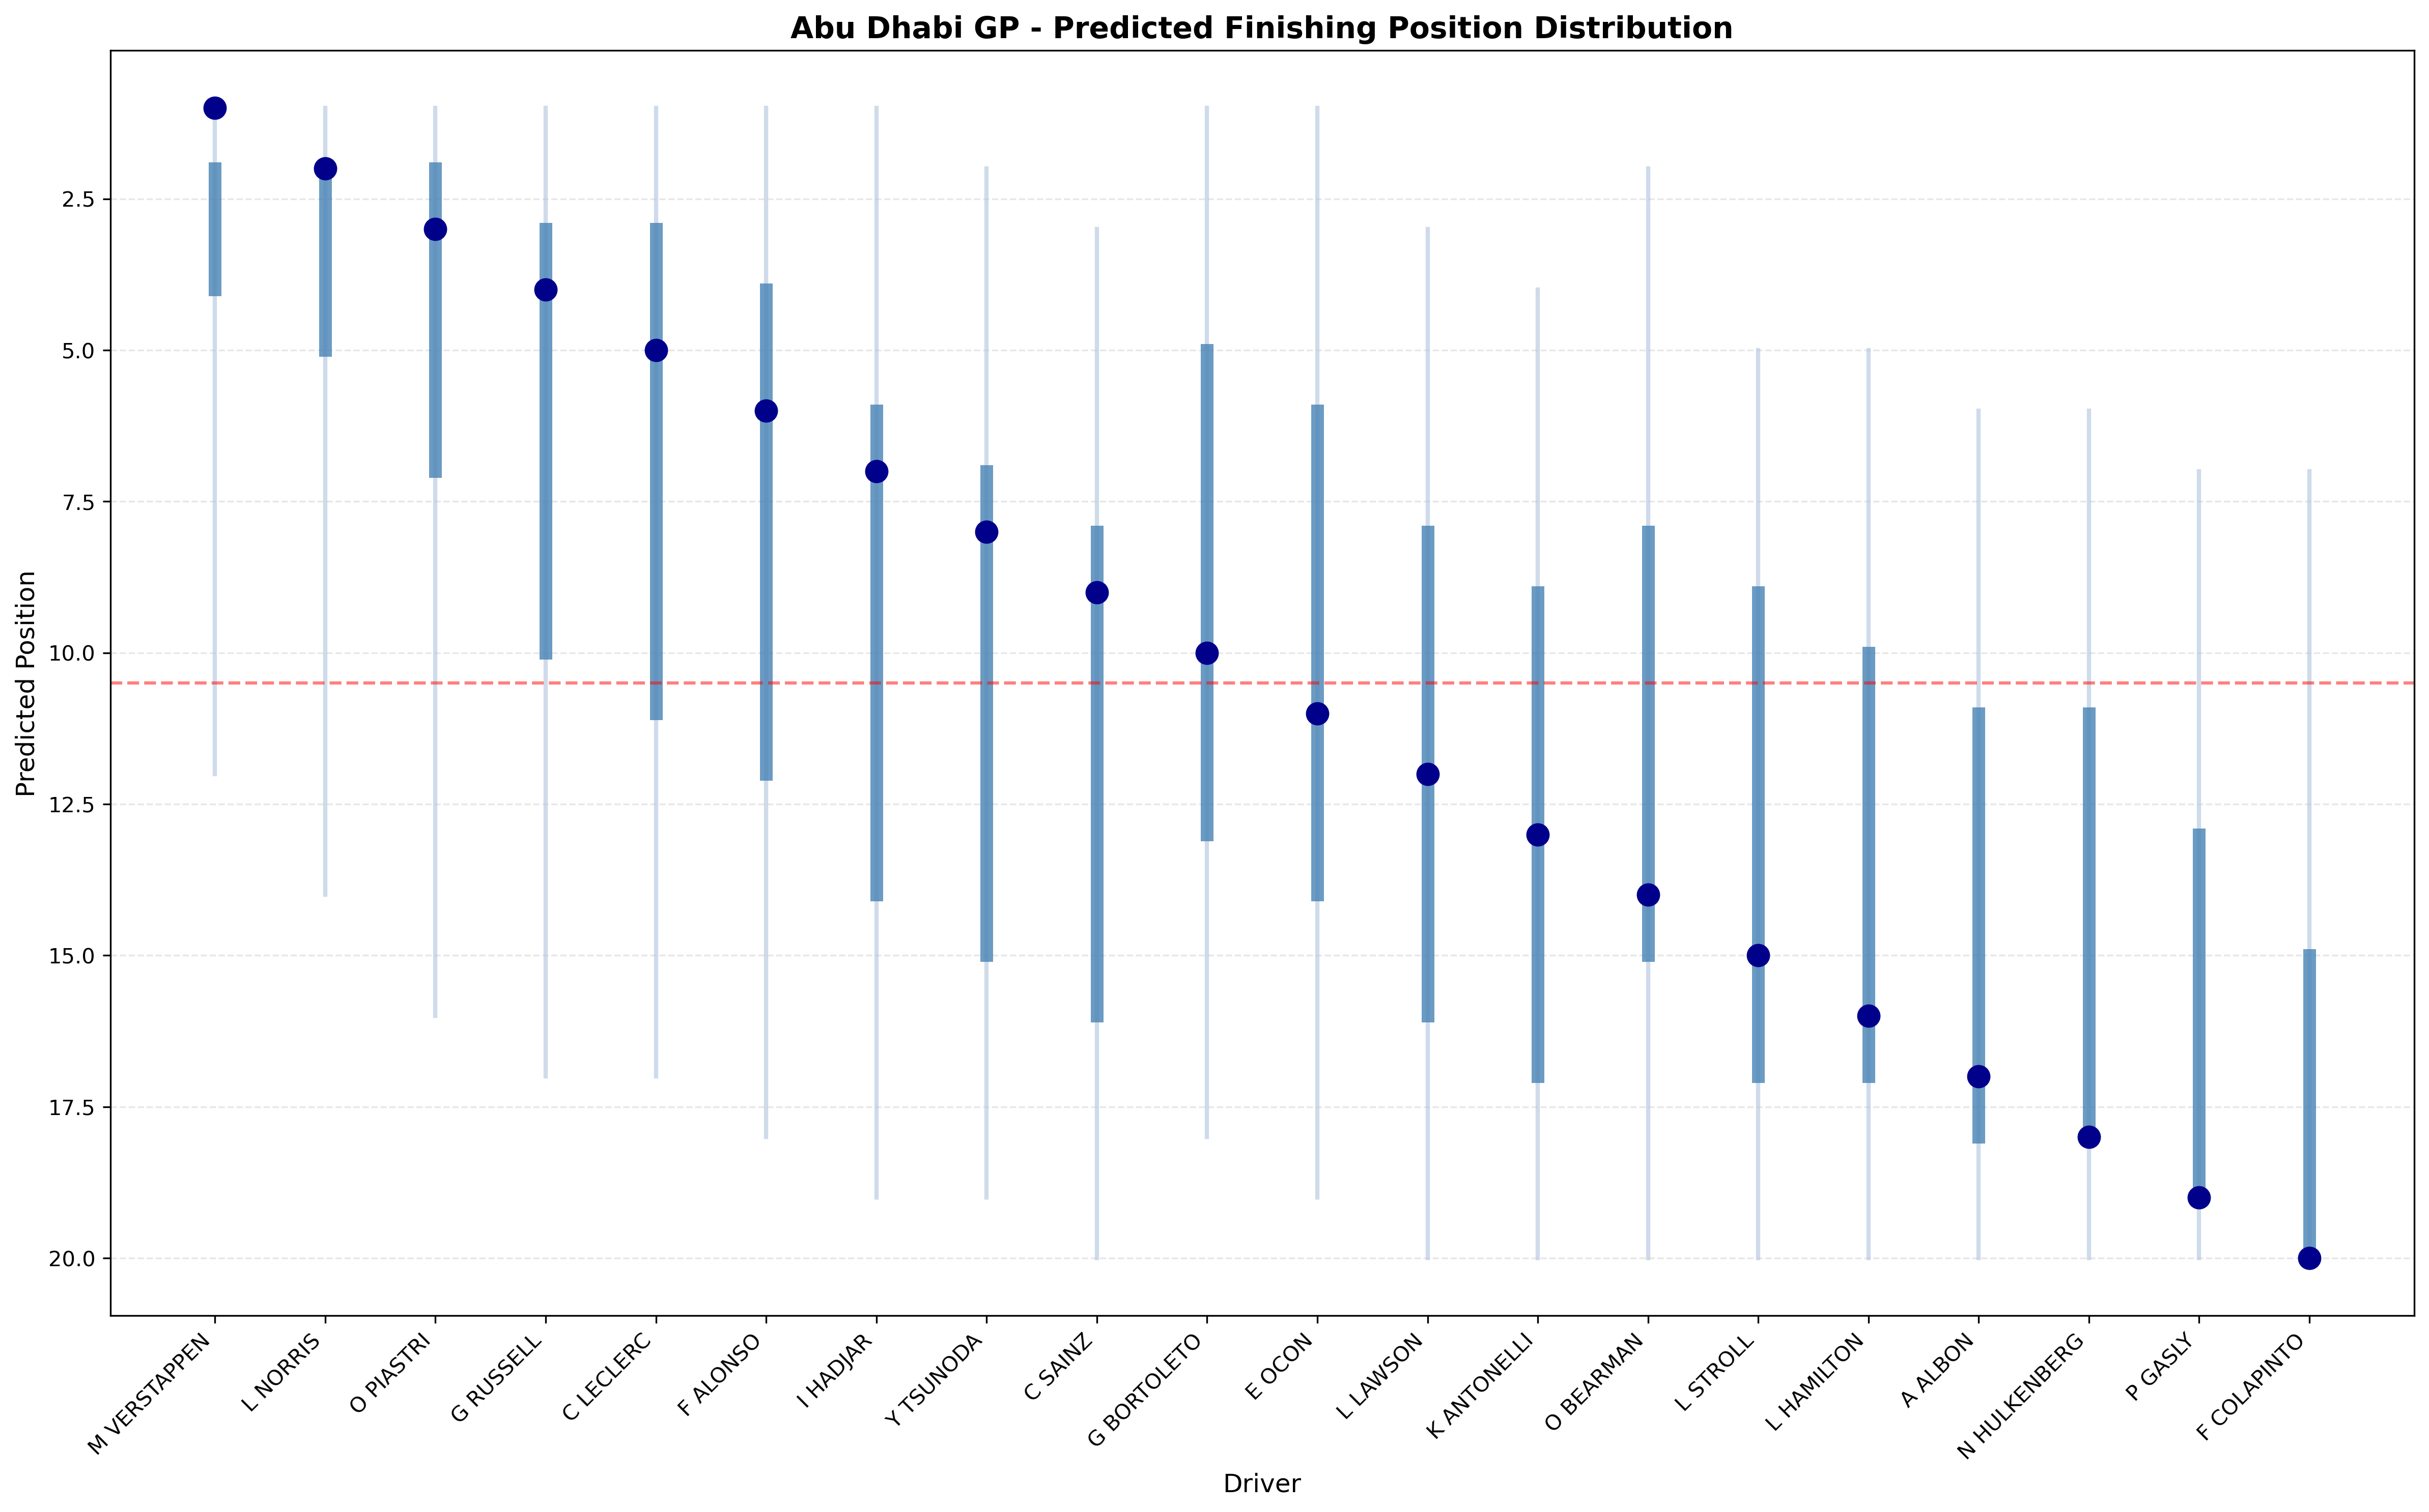

In [1]:
from IPython.display import Image, display

# Display the Abu Dhabi position distribution image
display(Image(filename='abu_dhabi_position_distribution.png'))

### result for 2025 total score

PredictedRank  ActualRank  RankDiff       Driver      Mean  Mode    P_Win   P_Top3  P_Top10
             1           1         0 M VERSTAPPEN  3.417200     1 0.239902 0.634022 0.961938
             2           3        -1     L NORRIS  4.332834     1 0.186250 0.532426 0.918906
             3           2         1    O PIASTRI  5.288408     2 0.145638 0.435910 0.867778
             4           5        -1    G RUSSELL  6.282590     3 0.112146 0.347050 0.809720
             5           4         1    C LECLERC  7.288670     5 0.083504 0.266594 0.746354
             6           6         0     F ALONSO  8.207728     5 0.062146 0.201318 0.682140
             7          17       -10     I HADJAR 10.290442     6 0.025336 0.086366 0.525236
             8          14        -6    Y TSUNODA 10.824124     7 0.018734 0.065098 0.483600
             9          13        -4      C SAINZ 11.784004     9 0.010220 0.036354 0.405762
            10          11        -1  G BORTOLETO  9.005408    10 0.045586 0.150214 0.625158
            11           7         4       E OCON  9.697490    10 0.034172 0.113838 0.571876
            12          18        -6     L LAWSON 12.225986    13 0.007454 0.026842 0.370162
            13          15        -2  K ANTONELLI 12.668230    13 0.005316 0.019442 0.335866
            14          12         2    O BEARMAN 11.315784    14 0.013970 0.048814 0.443144
            15          10         5     L STROLL 13.104912    15 0.003840 0.013816 0.303116
            16           8         8   L HAMILTON 13.579908    18 0.002604 0.009534 0.267966
            17          16         1      A ALBON 14.104578    19 0.001670 0.006242 0.232038
            18           9         9 N HULKENBERG 14.690962    20 0.000924 0.003726 0.195262
            19          19         0      P GASLY 15.421368    20 0.000450 0.001712 0.152662
            20          20         0  F COLAPINTO 16.469374    20 0.000138 0.000682 0.101316


# readme


## F1 Race Prediction - Hierarchical Bayesian Model

## Project Overview
This project implements a hierarchical Bayesian model to predict Formula 1 race outcomes using PyMC. The model incorporates team effects, driver abilities, grid positions, recent performance, and DNF rates to forecast final race positions and season standings.

## File Structure
```
project/
├── data/
│   ├── data_get.ipynb          # Data collection from FastF1 API
│   ├── data_clean.ipynb        # Data preprocessing and feature engineering
│   ├── driver_features.csv     # Processed driver-level features
│   └── drivers_info.csv        # Driver and team information
│
├── F1DataGet.ipynb             # Main data collection notebook
├── F1ModelBuild.ipynb          # Hierarchical Bayesian model construction
├── F1ModelExplain.ipynb        # Model interpretation and diagnostics
├── F1MTKL.ipynb               # Monte Carlo validation (model comparison)
│
├── F1_Final_predict.ipynb      # Final season predictions
├── F1 Predict ABU DHABI.ipynb  # Abu Dhabi GP prediction
├── F1 Predict Qatar.ipynb      # Qatar GP prediction
│
└── cache/                      # FastF1 API cache directory
```

## Execution Order

### Step 1: Data Collection and Cleaning
Run these notebooks in order to prepare the dataset:

1. **`F1DataGet/data_get.ipynb`** or **`F1DataGet.ipynb`**
   - Collects race data from FastF1 API for 2024-2025 seasons
   - Extracts race results, grid positions, DNF status
   - Saves raw data and populates `cache/` directory
```python
   # Key operations:
   # - Load race sessions
   # - Extract driver results
   # - Save to CSV
```

2. **`F1DataGet/data_clean.ipynb`**
   - Processes raw data and engineers features
   - Creates hierarchical data structure
   - Outputs: `driver_features.csv`, `drivers_info.csv`
```python
   # Key operations:
   # - Calculate recent_performance (rolling avg)
   # - Compute dnf_rate
   # - Classify team_tier
   # - Normalize variables
```

### Step 2: Model Development

3. **`F1ModelBuild.ipynb`**
   - Constructs hierarchical Bayesian model in PyMC
   - Implements team effects, driver effects, and interaction terms
   - Performs MCMC sampling with multiple chains
```python
   # Model structure:
   # - Team tier effects (hierarchical)
   # - Driver ability (nested within team)
   # - Covariates: grid position, recent performance, DNF rate
   # - Interaction: team_tier × driver_ability
```
   
   **Note**: Due to model complexity and interaction terms, fitting requires:
   - Testing multiple `random_seed` values for initialization
   - Using multiple chains (`chains=4`) for convergence
   - Optional: Baby step approach (fit simple model first, then expand)

4. **`F1ModelExplain.ipynb`**
   - Model diagnostics and convergence checks
   - Posterior analysis and effect interpretation
   - Visualizations of parameter estimates
```python
   # Key diagnostics:
   # - R-hat values (< 1.01)
   # - Effective sample size (> 400)
   # - Trace plots and posterior distributions
```

### Step 3: Model Validation

5. **`F1MTKL.ipynb`**
   - Monte Carlo validation of model performance
   - Compares Bayesian approach vs. simpler alternatives
   - Evaluates whether the complex hierarchical structure improves predictions
   
   Purpose: Determine if the sophisticated Bayesian model provides better predictions than baseline methods (e.g., using statistical rankings directly)

### Step 4: Predictions

6. **Race-specific prediction notebooks**:
   - `F1 Predict Qatar.ipynb` - Qatar GP predictions
   - `F1 Predict ABU DHABI.ipynb` - Abu Dhabi GP predictions
   - `F1_Final_predict.ipynb` - Final season standings prediction
   
   Each notebook:
   - Loads the trained model
   - Generates posterior predictive distributions
   - Outputs predicted positions and championship standings

## Requirements
```python
# Core dependencies
fastf1>=3.0.0
pymc>=5.0.0
arviz>=0.15.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
```

## Model Features

- **Hierarchical Structure**: Team-level and driver-level effects
- **Covariates**: Grid position, recent performance, DNF rates
- **Interaction Terms**: Team tier × driver ability
- **Sampling Strategy**: Multiple chains with careful initialization
- **Convergence**: R-hat diagnostics and ESS monitoring

## Key Results

- Model R² ≈ 0.50-0.56 for race position prediction
- Top 10 accuracy: ~80% using statistical ranking approach
- Constructor effects explain ~88% of variance in race outcomes

## Notes

- The `cache/` directory stores FastF1 API responses to avoid redundant calls
- Model fitting may take 10-30 minutes depending on data size and sampling parameters
- For convergence issues, try different `random_seed` values or use the baby step approach described in `F1ModelBuild.ipynb`